In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("breast.csv")

In [ ]:
print(df.head())


   samples   type  1007_s_at   1053_at    117_at    121_at  1255_g_at  \
0       84  basal   9.850040  8.097927  6.424728  7.353027   3.029122   
1       85  basal   9.861357  8.212222  7.062593  7.685578   3.149468   
2       87  basal  10.103478  8.936137  5.735970  7.687822   3.125931   
3       90  basal   9.756875  7.357148  6.479183  6.986624   3.181638   
4       91  basal   9.408330  7.746404  6.693980  7.333426   3.169923   

    1294_at   1316_at   1320_at  ...  AFFX-r2-Ec-bioD-3_at  \
0  6.880079  4.963740  4.408328  ...             12.229711   
1  7.542283  5.129607  4.584418  ...             12.178531   
2  6.562369  4.813449  4.425195  ...             12.125108   
3  7.802344  5.490982  4.567956  ...             12.111235   
4  7.610457  5.372469  4.424426  ...             12.173642   

   AFFX-r2-Ec-bioD-5_at  AFFX-r2-P1-cre-3_at  AFFX-r2-P1-cre-5_at  \
0             11.852955            13.658701            13.477698   
1             11.809408            13.750086      

In [ ]:
print(df.columns)
print(df.dtypes)

Index(['samples', 'type', '1007_s_at', '1053_at', '117_at', '121_at',
       '1255_g_at', '1294_at', '1316_at', '1320_at',
       ...
       'AFFX-r2-Ec-bioD-3_at', 'AFFX-r2-Ec-bioD-5_at', 'AFFX-r2-P1-cre-3_at',
       'AFFX-r2-P1-cre-5_at', 'AFFX-ThrX-3_at', 'AFFX-ThrX-5_at',
       'AFFX-ThrX-M_at', 'AFFX-TrpnX-3_at', 'AFFX-TrpnX-5_at',
       'AFFX-TrpnX-M_at'],
      dtype='object', length=54677)
samples              int64
type                object
1007_s_at          float64
1053_at            float64
117_at             float64
                    ...   
AFFX-ThrX-5_at     float64
AFFX-ThrX-M_at     float64
AFFX-TrpnX-3_at    float64
AFFX-TrpnX-5_at    float64
AFFX-TrpnX-M_at    float64
Length: 54677, dtype: object


### Identify Gene Expression Columns
* **Goal:** Isolate the columns that hold expression values.
* **Method:** Filter by a naming pattern—here, probe IDs typically end with _at.

In [ ]:
gene_columns = [col for col in df.columns if col.endswith('_at')]
print("Number of gene expression columns:", len(gene_columns))


Number of gene expression columns: 54675


### Separate Clinical and Expression Data:
* **Goal:** Keep clinical/metadata separate from expression data for clarity.
* **Action:** Create two new DataFrames:

In [ ]:
clinical_cols = ['samples', 'type']  # Add any other clinical columns if present
clinical_df = df[clinical_cols]
expression_df = df[gene_columns]

Result:
* clinical_df now holds the patient IDs and types.
* expression_df holds all numeric gene expression values.

In [ ]:
#Confirm Data Types Are Correct:
# Action: Check that the expression DataFrame contains only numeric data.
print(expression_df.dtypes.unique())

[dtype('float64')]


### Step 3: Data Cleaning – Handling Missing Values and Ensuring Quality

#### Identify Missing Values in the Whole Dataset:
* Goal: See if there are any missing (NaN) values that might affect your analysis.

In [ ]:
total_missing = df.isnull().sum().sum()
print("Total missing values in entire dataset:", total_missing)

Total missing values in entire dataset: 0


### Check Missing Values in the Expression Data Only:
* Check how many missing values are in our expression DataFrame.

In [ ]:
missing_expression = expression_df.isnull().sum().sum()
print("Total missing values in expression data:", missing_expression)

Total missing values in expression data: 0


### Check for Outliers and Verify Distributions
* Generate Descriptive Statistics to see if the numeric values fall within a reasonable range. Look at the min, max, mean, and quartiles. Extreme values or unexpected ranges may indicate outliers.

In [ ]:
print(expression_df.describe())

        1007_s_at     1053_at      117_at      121_at   1255_g_at     1294_at  \
count  151.000000  151.000000  151.000000  151.000000  151.000000  151.000000   
mean    10.338901    7.631910    6.224885    7.339248    3.185252    7.310240   
std      0.613445    0.706464    0.645435    0.330827    0.158909    0.642091   
min      7.505488    5.855968    4.763602    6.632206    2.760583    5.455736   
25%     10.103030    7.166075    5.798087    7.105841    3.075873    6.874504   
50%     10.416819    7.531673    6.235074    7.333426    3.187703    7.417113   
75%     10.735117    8.053832    6.612291    7.513084    3.280416    7.760806   
max     11.675109    9.627008    8.364749    8.374055    3.611630    8.569296   

          1316_at     1320_at   1405_i_at     1431_at  ...  \
count  151.000000  151.000000  151.000000  151.000000  ...   
mean     5.323484    4.714095    7.787712    3.902061  ...   
std      0.294513    0.308550    1.648260    0.481294  ...   
min      4.646131    3

### Quick Visualization To Understand Overall Distribution of Gene Expression Data

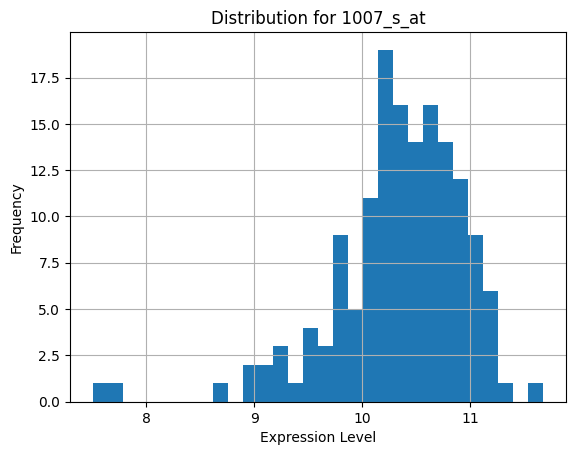

In [ ]:
import matplotlib.pyplot as plt
expression_df['1007_s_at'].hist(bins=30)
plt.title("Distribution for 1007_s_at")
plt.xlabel("Expression Level")
plt.ylabel("Frequency")
plt.show()


### What do we notice?

* **No Major Outliers:** You don’t see any data points way off on the low or high end (e.g., a cluster of values near 1 or 15), so there’s no glaring reason to suspect faulty measurements or weird artifacts.
* **Decent Spread:** The histogram shows a range from about 8 to ~12, which suggests you have some variability in expression for this gene. Variability is helpful because a gene that never changes expression is less informative for co-expression analysis.

* **Likely Already on a Log Scale:** Microarray expression values around 10 typically indicate a log-based scale (common in many microarray normalization pipelines). If so, you probably don’t need an additional log transform.

### Filtering Genes By Variance

In [3]:
def filter_genes_by_variance(
    expression_df: pd.DataFrame,
    k: int = None,
    min_variance: float = None,
    log_transform: bool = False,
    log_base: int = 2,
    verbose: bool = True
) -> pd.DataFrame:
    """
    This module provides a function to filter genes by variance from an expression DataFrame.

    The function supports an optional log transform and two strategies:
    1. Selecting the top k genes by variance.
    2. Selecting genes whose variance is at least a given minimum.
    It returns a filtered DataFrame containing only the chosen gene expression columns.

    Example usage:
        >>> import pandas as pd
        >>> import numpy as np
        >>> # Create a simple DataFrame with made-up data
        >>> data = {'gene1': [1, 2, 3, 4],
        ...         'gene2': [2, 2, 2, 2],
        ...         'gene3': [5, 7, 9, 11],
        ...         'gene4': [10, 10, 10, 10]}
        >>> df = pd.DataFrame(data)
        >>> # For gene3, the sample variance is 6.666667, and for gene1 it is 1.666667.
        >>> filtered = filter_genes_by_variance(df, k=2, log_transform=False)
        Computing variance for each gene...
        Initial number of genes (columns) in expression_df: 4
        Selecting top 2 genes by variance...
        Number of genes after filtering: 2
        Top 5 highest-variance genes in the filtered set:
        gene3    6.666667
        gene1    1.666667
        dtype: float64
        >>> filtered.columns.tolist()  # Should contain the 2 highest-variance genes
        ['gene3', 'gene1']
    """


    # Safety checks
    if expression_df.isnull().sum().sum() > 0:
        raise ValueError("DataFrame contains missing values; please handle them before calling this function.")

    # 1. Optional log transform (if user requests it)
    df_to_filter = expression_df.copy()
    if log_transform:
        if verbose:
            print(f"Applying log{log_base} transform to the expression data...")

        if log_base == 2:
            df_to_filter = df_to_filter.apply(lambda col: np.log2(col + 1), axis=0)
        elif log_base == 10:
            df_to_filter = df_to_filter.apply(lambda col: np.log10(col + 1), axis=0)
        else:
            # fallback for arbitrary log base
            df_to_filter = df_to_filter.apply(lambda col: np.log(col + 1) / np.log(log_base), axis=0)

    # 2. Calculate variance column-wise
    if verbose:
        print("Computing variance for each gene...")

    variances = df_to_filter.var(axis=0)

    if verbose:
        print("Initial number of genes (columns) in expression_df:", df_to_filter.shape[1])

    # 3. Determine filter method (top k or min_variance)
    filtered_df = None
    if k is not None:
        # top k approach
        if verbose:
            print(f"Selecting top {k} genes by variance...")

        top_genes = variances.nlargest(k).index
        filtered_df = df_to_filter[top_genes]

    elif min_variance is not None:
        # variance threshold approach
        if verbose:
            print(f"Selecting genes with variance >= {min_variance}...")

        pass_mask = (variances >= min_variance)
        # get the gene IDs that pass
        passing_genes = variances[pass_mask].index
        filtered_df = df_to_filter[passing_genes]
    else:
        # If neither k nor min_variance is specified, no filtering is done
        if verbose:
            print("No k or min_variance specified; returning the original DataFrame.")
        filtered_df = df_to_filter

    # 4. Print results
    if verbose and filtered_df is not None:
        print("Number of genes after filtering:", filtered_df.shape[1])
        # Show top 5 highest-variance genes in the filtered set (for curiosity)
        # Recompute variance in case we transformed
        filtered_variances = filtered_df.var(axis=0).sort_values(ascending=False)
        top_5 = filtered_variances.head(5)
        print("Top 5 highest-variance genes in the filtered set:")
        print(top_5)

    return filtered_df
import doctest
    doctest.testmod()

    # For Colab, you can also run:
    sample_data = {'gene1': [1, 2, 3, 4],
                   'gene2': [2, 2, 2, 2],
                   'gene3': [5, 7, 9, 11],
                   'gene4': [10, 10, 10, 10]}
    df = pd.DataFrame(sample_data)
    filtered = filter_genes_by_variance(df, k=2, log_transform=False)
    print("Filtered genes:", filtered.columns.tolist())

    # Optionally, run Python TA without using __file__ (Colab doesn't define __file__)
    import python_ta
        python_ta.check_all(config={
            'max-line-length': 120,
            'disable': ['E1136', 'W0221'],
            'max-nested-blocks': 4
        })
    except Exception as e:
        print("Python TA encountered an error:", e)

NameError: name 'pd' is not defined

In [ ]:
# Suppose original expression DataFrame is expression_df
# we have 151 samples x 54675 genes (approx).

# Example 1: Keep top 1000 genes by variance, no log transform
filtered_df = filter_genes_by_variance(
    expression_df,
    k=1000,
    log_transform=False,
    verbose=True
)


Computing variance for each gene...
Initial number of genes (columns) in expression_df: 54675
Selecting top 1000 genes by variance...
Number of genes after filtering: 1000
Top 5 highest-variance genes in the filtered set:
206378_at     17.083996
228241_at     13.367385
205916_at     11.137314
237339_at     10.873480
1553602_at    10.690823
dtype: float64


### Compute Pearson Correlation

#### Definition of Pearson
* Pearson’s r is a measure of linear correlation between two sets of numerical values (here, the expression levels of two genes across your samples). The result ranges from − 1(perfect negative correlation) through  0 (no linear relationship) to  + 1 (perfect positive correlation).
* **Why Pearson for Co-Expression Simple Interpretation:** If two genes have high expression values together (and low values together) across many samples, you get a positive  r

In [ ]:
corr_matrix = filtered_df.corr(method='pearson')
print("Correlation matrix shape:", corr_matrix.shape)


Correlation matrix shape: (1000, 1000)


In [ ]:
print(corr_matrix.iloc[:5, :5])


            206378_at  228241_at  205916_at  237339_at  1553602_at
206378_at    1.000000   0.532015  -0.032316   0.486878    0.550963
228241_at    0.532015   1.000000  -0.321957   0.689226    0.143547
205916_at   -0.032316  -0.321957   1.000000  -0.283678    0.330608
237339_at    0.486878   0.689226  -0.283678   1.000000    0.345226
1553602_at   0.550963   0.143547   0.330608   0.345226    1.000000


### Constructing the Graph

* Firstly, we define a correlation threshold – here we set threshold = 0.8 to capture strong correlations, and use a boolean use_absolute to decide if we want to include negative correlations (abs(r) >= 0.8) or only positive ones.
* We import networkx and create an empty graph G = nx.Graph(). This is our co-expression network, initially with no nodes or edges.
* We extract the list of gene IDs from corr_matrix.columns, which correspond to the columns of the correlation matrix (e.g., your 1,000 high-variance genes).
* We add each gene as a node in the graph with G.add_nodes_from(gene_list). This step ensures all genes exist in the graph before we create edges.
* Next, we loop over the upper triangle of the correlation matrix using two nested for loops (i in range(len(gene_list)), j in range(i+1, ...)). We do this because correlation matrices are symmetric and we don’t want duplicate edges.
* Inside the loop, we check the correlation value r_val = corr_matrix.iloc[i, j]. If use_absolute is True, we test abs(r_val) against the threshold; otherwise, we test r_val itself.
* If the correlation meets or exceeds the threshold, we add an edge with 'weight' set to r_val, effectively linking the two genes in the network. We also increment edges_added to count how many edges get created.
Finally, we print the total number of edges added and also the final node/edge counts (G.number_of_nodes(), G.number_of_edges()) to summarize our resulting co-expression network.

Number of nodes after adding genes: 100
-----------------------------------------------
Nodes in G: 100
Edges in G: 462
Number of edges added: 462
Average degree in the network: 9.24


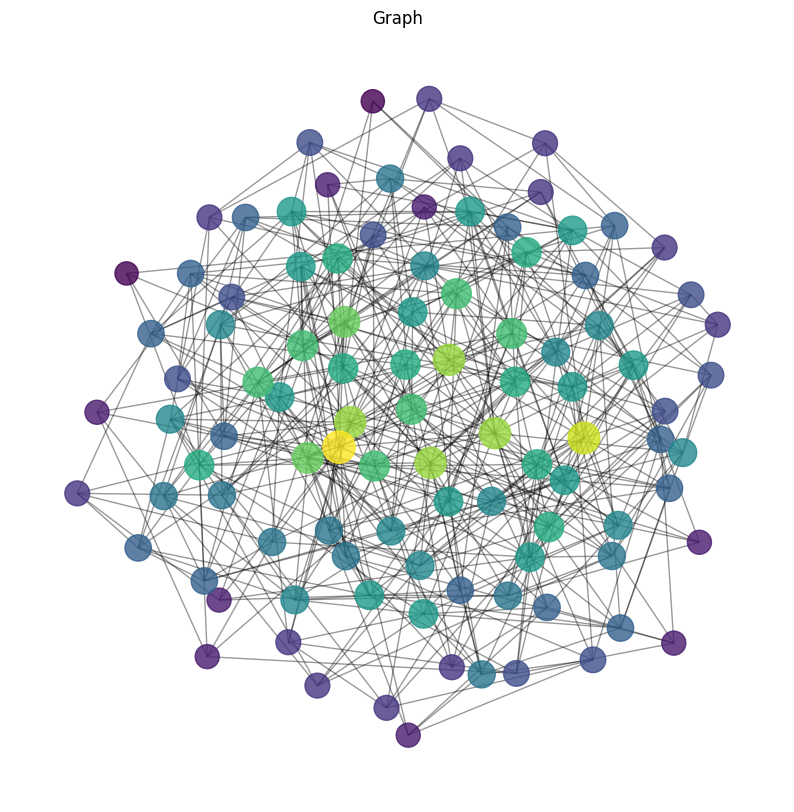

In [ ]:
# 1) Generate a random correlation matrix for demonstration
import networkx as nx
import statistics
np.random.seed(42)
data = np.random.normal(size=(100, 100))
corr_matrix = pd.DataFrame(data).corr()

threshold = 0.17
use_absolute = True

# 2) Create an empty graph
G = nx.Graph()

# 3) Get the gene list (column names). For our random data, they're just 0..99
gene_list = corr_matrix.columns

G.add_nodes_from(gene_list)
print("Number of nodes after adding genes:", G.number_of_nodes())

edges_added = 0

# 4) Build edges based on threshold
for i in range(len(gene_list)):
    for j in range(i + 1, len(gene_list)):
        r_val = corr_matrix.iloc[i, j]

        if use_absolute:
            if abs(r_val) >= threshold:
                dist = 1 - abs(r_val)  # distance in [0,1], 0 means correlation=1
                G.add_edge(gene_list[i], gene_list[j], weight=dist)
                edges_added += 1
        else:
            if r_val >= threshold:
                dist = 1 - r_val
                G.add_edge(gene_list[i], gene_list[j], weight=dist)
                edges_added += 1

print("-----------------------------------------------")
print("Nodes in G:", G.number_of_nodes())
print("Edges in G:", G.number_of_edges())
print("Number of edges added:", edges_added)

degrees = dict(G.degree())
avg_degree = statistics.mean(degrees.values()) if degrees else 0
print(f"Average degree in the network: {avg_degree:.2f}")

# 5) Compute Kamada–Kawai layout
pos = nx.kamada_kawai_layout(G, weight='weight')

# 6) Generate node color and size from degree
if len(degrees) == 0:
    # If no edges above threshold, no layout to plot
    print("No edges were added—try lowering the threshold.")
else:
    max_deg = max(degrees.values())
    node_color = []
    node_size = []

    for node in G.nodes():
        deg_val = degrees[node]
        # scale color to [0..1]
        color_val = deg_val / max_deg if max_deg != 0 else 0
        node_color.append(color_val)
        # size formula: base 200 plus 20 * deg
        node_size.append(200 + deg_val * 20)

    # 7) Draw the graph
    plt.figure(figsize=(10, 10))

    nx.draw_networkx_nodes(
        G,
        pos=pos,
        node_color=node_color,
        node_size=node_size,
        cmap=plt.cm.viridis,
        alpha=0.8
    )

    nx.draw_networkx_edges(G, pos=pos, alpha=0.4)
    # Optionally label the nodes (can get messy)
    # nx.draw_networkx_labels(G, pos=pos, font_size=6)

    plt.title(f"Graph")
    plt.axis("off")
    plt.show()

### Girvan-Newman Algorithm

* **Start with the Full Network:** You begin with your complete network G where all genes are connected by edges if their correlation (above a threshold) passes your criterion.
* **Compute Edge Betweenness:**
For each edge, the algorithm calculates its betweenness—that is, how many of the shortest paths between all pairs of nodes pass through that edge. Edges that connect different communities tend to have high betweenness.
* **Remove the Highest-Betweenness Edge:**
The edge with the highest betweenness is removed from the network because it likely acts as a bridge between communities. This is the key “cut” that begins to split the network.
* **Iterate:**
The process repeats—after removing an edge, the algorithm recalculates betweenness values (since the network structure has changed) and removes the next highest. This iterative removal produces a sequence of different community partitions.
* **Evaluate Partitions:**
At each iteration, a partition (a split of the network into communities) is generated. We compute a measure called modularity to assess how well the network is divided. A higher modularity score indicates a better, more meaningful community split.
* **Select the Best Partition:**
After several iterations (in our code, we loop up to 5 times), we choose the partition with the highest modularity as our best community structure.
* **Visualize:**
Finally, we map each node to its community, assign colors accordingly, and display the network using a layout (like a spring layout) so you can see the resulting communities.

Evaluating partitions via Girvan-Newman:
Iteration 1: 2 communities, modularity = -0.0001
Iteration 2: 3 communities, modularity = 0.0020
Iteration 3: 4 communities, modularity = 0.0018
Iteration 4: 5 communities, modularity = 0.0016
Iteration 5: 6 communities, modularity = 0.0033

Best partition found at iteration 5 with 6 communities and modularity 0.0033.


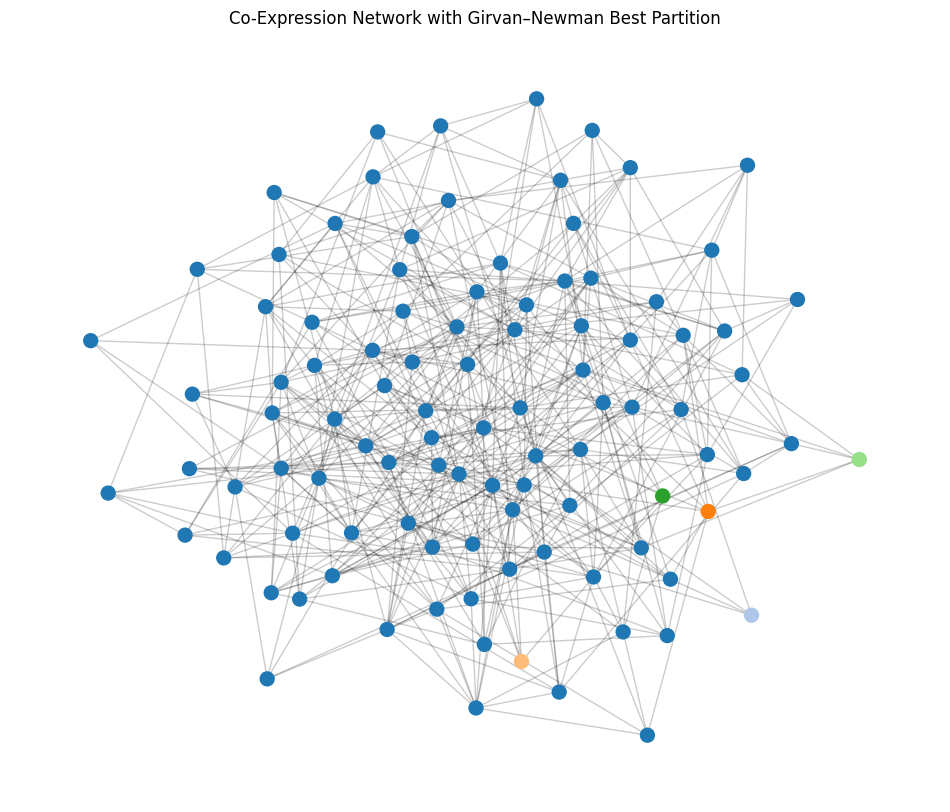

In [ ]:

from networkx.algorithms.community import girvan_newman
from networkx.algorithms.community.quality import modularity


# -----------------------------------------------------------------------------
# Step 1: Initialize the Girvan–Newman generator
# -----------------------------------------------------------------------------
# The girvan_newman function returns a generator that yields partitions at
# successive levels of edge removal.
communities_generator = girvan_newman(G)

# -----------------------------------------------------------------------------
# Step 2: Iterate over several levels to examine different community splits
# -----------------------------------------------------------------------------
max_levels = 5  # You can adjust this to check more levels if desired
partitions = []  # To store each partition (community structure)
mod_scores = []  # To store modularity score at each iteration

print("Evaluating partitions via Girvan-Newman:")
for i in range(max_levels):
    try:
        # Get the next partition: a tuple of sets (each set is a community)
        current_partition = next(communities_generator)
    except StopIteration:
        # If there are no more partitions, break out of the loop.
        break

    # Append the current partition
    partitions.append(current_partition)

    # Compute modularity of the current partition.
    # 'modularity' evaluates how good the partition is,
    # higher values indicate better separation of communities.
    current_mod = modularity(G, current_partition, weight='weight')
    mod_scores.append(current_mod)

    # Print information about this iteration
    print(f"Iteration {i+1}: {len(current_partition)} communities, modularity = {current_mod:.4f}")

# -----------------------------------------------------------------------------
# Step 3: Select the Best Partition Based on Modularity
# -----------------------------------------------------------------------------
if mod_scores:
    best_index = mod_scores.index(max(mod_scores))
    best_partition = partitions[best_index]
    print(f"\nBest partition found at iteration {best_index+1} with {len(best_partition)} communities and modularity {mod_scores[best_index]:.4f}.")
else:
    best_partition = (set(G.nodes()),)  # Fallback: all nodes in one community
    print("No partition generated; using the entire graph as one community.")

# -----------------------------------------------------------------------------
# Step 4: (Optional) Visualize the Best Partition on the Graph
# -----------------------------------------------------------------------------
# We'll color nodes by their community assignment
# First, create a dictionary mapping each node to its community ID
community_map = {}
for idx, community in enumerate(best_partition):
    for node in community:
        community_map[node] = idx

# Choose a colormap (we use a discrete one for clarity)
import matplotlib.cm as cm
num_communities = len(best_partition)
color_map = [cm.tab20(community_map[node] % 20) for node in G.nodes()]

# Use a spring layout for visualization, since it tends to work well with community structure
pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(12, 10))
nx.draw_networkx_edges(G, pos, alpha=0.2)
nx.draw_networkx_nodes(G, pos, node_color=color_map, node_size=100)
plt.title("Co-Expression Network with Girvan–Newman Best Partition")
plt.axis("off")
plt.show()


### Identify Hub Genes

* We calculate degree centrality (deg_cent) to see which nodes (genes) have the most edges—i.e., correlated with many others above the threshold.
* We also compute betweenness centrality (bet_cent) to find nodes that act as “bridges” connecting different parts of the network.
* We sort each measure in descending order and take the top 5, effectively listing the most “hub-like” genes by each criterion.
* Finally, we print these top 5 sets of genes, giving a quick view of who the main players (hubs) might be in the co-expression network.

In [ ]:
deg_cent = nx.degree_centrality(G)
bet_cent = nx.betweenness_centrality(G, normalized=True, weight='weight')
# Sort and see top 5 hubs
top_deg = sorted(deg_cent.items(), key=lambda x: x[1], reverse=True)[:5]
top_bet = sorted(bet_cent.items(), key=lambda x: x[1], reverse=True)[:5]
print("Top 5 by Degree Centrality:", top_deg)
print("Top 5 by Betweenness Centrality:", top_bet)


Top 5 by Degree Centrality: [(92, 0.17171717171717174), (9, 0.16161616161616163), (13, 0.15151515151515152), (81, 0.15151515151515152), (84, 0.15151515151515152)]
Top 5 by Betweenness Centrality: [(92, 0.058544629973201395), (1, 0.03463203463203463), (14, 0.03339517625231911), (30, 0.03050917336631622), (89, 0.029066171923314777)]


### Visualization

* Girvan–Newman Communities Plot  
1. Each color corresponds to a distinct community found by the Girvan–Newman algorithm.
2. The largest set of nodes share the same color, meaning they ended up in the same big cluster.
3. A few nodes on the periphery have unique colors, indicating small or singleton communities.
4. Edges are drawn with partial transparency, so the dense network doesn’t become a black blob.
5. The layout is typically a spring layout, spreading nodes so that correlated clusters appear near each other.
6. This visualization reveals that the network doesn’t split into many big groups—most nodes remain in one major community.
*  Degree Centrality Visualization
1. Node color is mapped to each gene’s degree (number of edges), from low-degree (e.g., purple/blue) to high-degree (green/yellow).
2. The bright yellow node(s) near the center are hub genes connected to many others above the threshold.
3. Nodes on the outer edges often have fewer edges, so they appear in darker or cooler tones.
4. The same partial-transparency edges show the overall structure without overwhelming the view.
5. This layout (likely Kamada–Kawai or a spring layout) clusters highly connected genes toward the center.
6. By visually scanning for large, bright nodes, you quickly spot major “influencers” in the co-expression network.

* Interactive Gene Co-Expression Network

This figure shows a gene co-expression network derived from correlation data. Each circle (node) represents a gene, and edges connect pairs of genes whose correlation exceeds the chosen threshold. Nodes are colored according to how many strong correlations (edges) they have, with more connected (high-degree) genes shown in lighter/brighter colors. The interactive aspect lets you hover or click on nodes/edges to see their labels and values


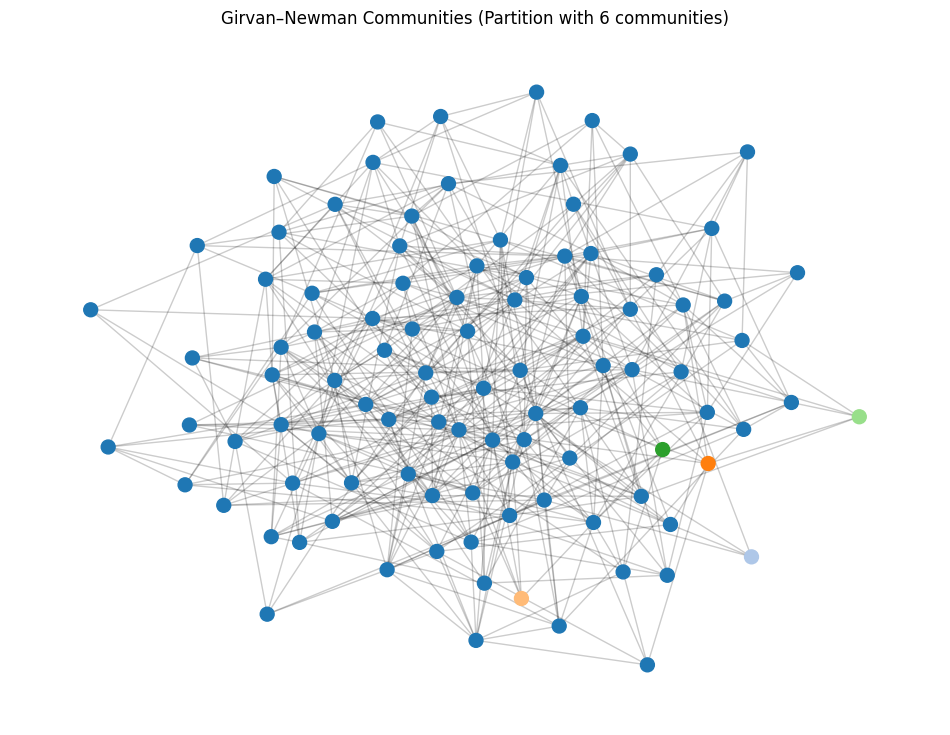

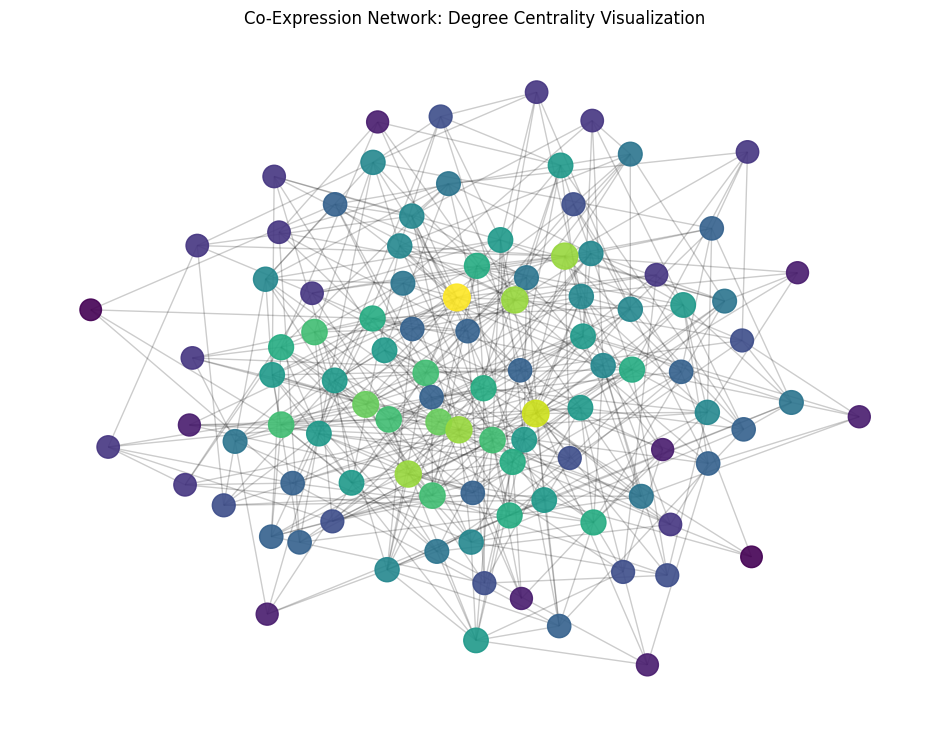

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import networkx as nx

# ------------------------
# Assume you have:
# 1) A networkx.Graph() named G
# 2) A best_partition from Girvan–Newman
# 3) A layout (pos) or you can compute a new one
# For example:
# pos = nx.spring_layout(G, seed=42)
# ------------------------

###################################
# PART A: COMMUNITY PARTITION PLOT
###################################
def visualize_communities(G, best_partition, pos):
    # 1) Build a node -> community map
    community_map = {}
    for idx, community in enumerate(best_partition):
        for node in community:
            community_map[node] = idx

    # 2) Create a color list for each node
    num_communities = len(best_partition)
    node_colors = [cm.tab20(community_map[n] % 20) for n in G.nodes()]

    plt.figure(figsize=(12, 9))
    # Draw edges
    nx.draw_networkx_edges(G, pos, alpha=0.2)
    # Draw nodes colored by community
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=100)
    plt.title(f"Girvan–Newman Communities (Partition with {num_communities} communities)")
    plt.axis('off')
    plt.show()

###################################
# PART B: HUB CENTRALITY PLOT
###################################
def visualize_centrality(G, pos, measure='degree'):
    # 1) Compute centralities
    if measure == 'degree':
        centrality = nx.degree_centrality(G)
    elif measure == 'betweenness':
        centrality = nx.betweenness_centrality(G, normalized=True, weight='weight')
    else:
        # default to degree
        centrality = nx.degree_centrality(G)

    # 2) Scale node sizes & colors
    values = list(centrality.values())
    max_val = max(values) if values else 1
    node_color = []
    node_size = []
    for n in G.nodes():
        cent_val = centrality[n]
        node_color.append(cent_val / max_val)  # scaled 0..1
        node_size.append(200 + cent_val * 1000)  # scale size for emphasis

    # 3) Plot
    plt.figure(figsize=(12, 9))
    nx.draw_networkx_edges(G, pos, alpha=0.2)
    nx.draw_networkx_nodes(
        G, pos,
        node_color=node_color,
        cmap=plt.cm.viridis,
        node_size=node_size,
        alpha=0.9
    )
    plt.title(f"Co-Expression Network: {measure.capitalize()} Centrality Visualization")
    plt.axis('off')
    plt.show()

###################################
# USAGE EXAMPLE
###################################
# Suppose you have 'best_partition' from the Girvan–Newman code
# and a layout 'pos = nx.spring_layout(G, seed=42)':

# 1) Visualize communities
visualize_communities(G, best_partition, pos)

# 2) Visualize hubs with degree centrality
visualize_centrality(G, pos, measure='degree')

# or use betweenness
# visualize_centrality(G, pos, measure='betweenness')


In [ ]:
import networkx as nx
import plotly.graph_objs as go



pos = nx.spring_layout(G, seed=42)  # or kamada_kawai_layout(G)
edge_x = []
edge_y = []
for u, v in G.edges():
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

edge_trace = go.Scatter(
    x=edge_x,
    y=edge_y,
    mode='lines',
    line=dict(color='gray', width=1),
    hoverinfo='none'
)

node_x = []
node_y = []
for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)

node_trace = go.Scatter(
    x=node_x,
    y=node_y,
    mode='markers',
    marker=dict(
        showscale=True,
        colorscale='Viridis',
        color=[],
        size=10,
        line_width=2
    ),
    text=[str(n) for n in G.nodes()],
    hoverinfo='text'
)

degrees = dict(G.degree())
max_deg = max(degrees.values()) if len(degrees) else 1
node_colors = [degrees[n]/max_deg for n in G.nodes()]
node_trace.marker.color = node_colors

fig = go.Figure(data=[edge_trace, node_trace],
                layout=go.Layout(
                    title='Interactive Gene Co-Expression Network',
                    showlegend=False,
                    hovermode='closest',
                    margin=dict(b=20,l=5,r=5,t=40),
                )
               )

fig.show()
